In [2]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

In [4]:


import os

print(os.getcwd())

c:\Users\MNA\Downloads\Project1_decodelab_datascience


In [5]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [6]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

Shape of Dataset: (1200, 14)

Column Names
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')

Data Types
OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [8]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [9]:
df.describe(include='object')

,OrderID,CustomerID,Product,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,CouponCode,ReferralSource
count,1200,1200,1200,1200,1200,1200,1200,891,1200
unique,1200,1189,7,655,5,5,1200,3,5
top,ORD200000,C98474,Printer,533 Main St,Online,Cancelled,TRK37947903,FREESHIP,Instagram
freq,1,2,181,8,258,250,1,313,259


In [10]:
missing = df.isnull().sum()

missing

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [11]:
missing_percentage = (df.isnull().sum()/len(df))*100

missing_df = pd.DataFrame({
    "Missing Values":df.isnull().sum(),
    "Percentage":missing_percentage
})

missing_df

,Missing Values,Percentage
OrderID,0,0.00
Date,0,0.00
CustomerID,0,0.00
Product,0,0.00
Quantity,0,0.00
UnitPrice,0,0.00
ShippingAddress,0,0.00
PaymentMethod,0,0.00
OrderStatus,0,0.00
TrackingNumber,0,0.00


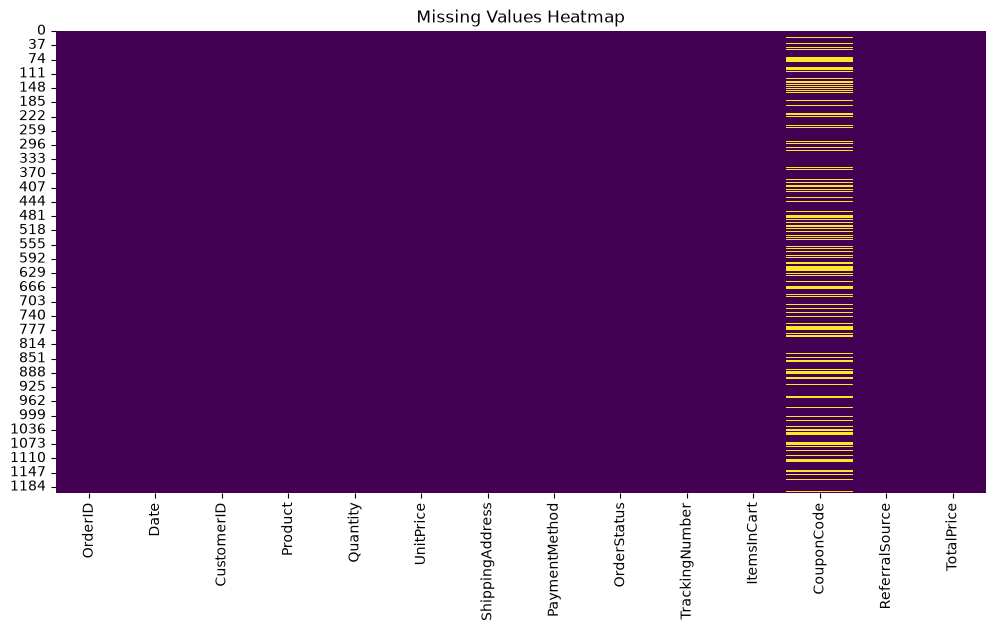

In [12]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

No missing values were found in the dataset. Therefore, no missing value treatment was required.

In [13]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


No duplicate rows were found.

In [14]:

df["Date"] = pd.to_datetime(df["Date"])

df["Date"].head()

0   2023-01-04
1   2024-08-23
2   2024-02-27
3   2023-10-15
4   2025-05-08
Name: Date, dtype: datetime64[us]

In [15]:
df["AveragePricePerItem"] = df["TotalPrice"] / df["Quantity"]

In [16]:
df["OrderYear"] = df["Date"].dt.year

In [17]:
df["OrderMonth"] = df["Date"].dt.month_name()

In [18]:
df["OrderDay"] = df["Date"].dt.day_name()

In [19]:
df["WeekendOrder"] = df["Date"].dt.dayofweek >= 5

In [20]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,AveragePricePerItem,OrderYear,OrderMonth,OrderDay,WeekendOrder
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,570.62,2023,January,Wednesday,False
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,151.35,2024,August,Friday,False
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,550.68,2024,February,Tuesday,False
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19,2023,October,Sunday,True
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,626.01,2025,May,Thursday,False


In [21]:
numerical_columns = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice"
]

numerical_columns

['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

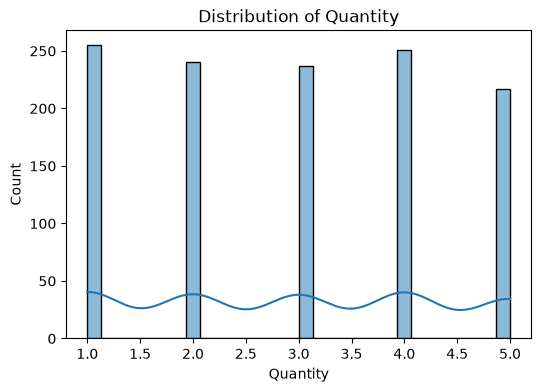

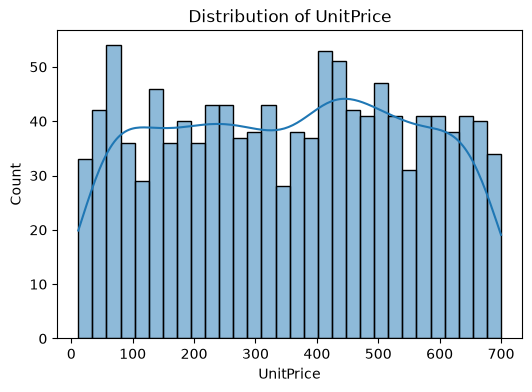

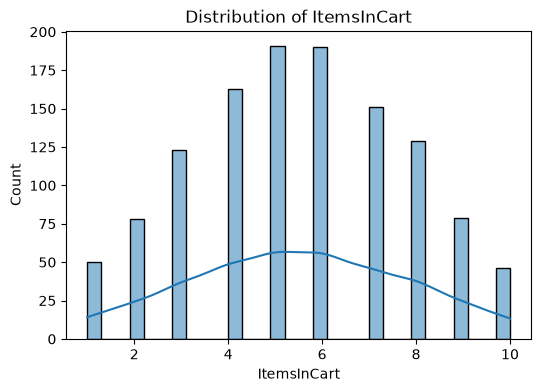

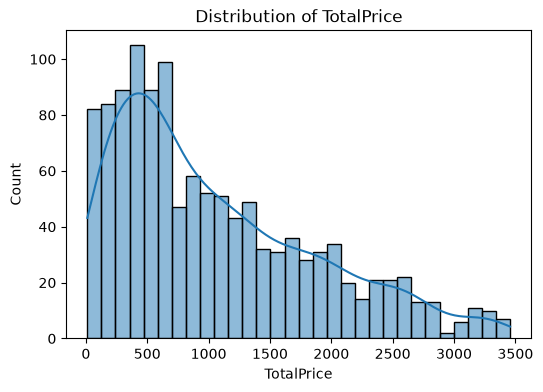

In [22]:
for col in numerical_columns:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col],
                 kde=True,
                 bins=30)

    plt.title(f"Distribution of {col}")

    plt.show()

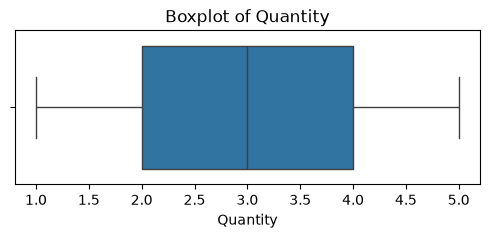

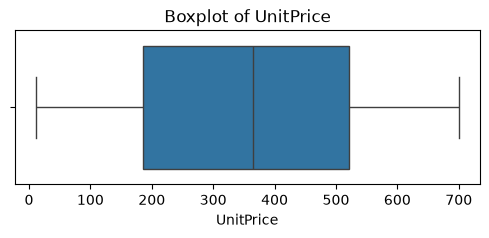

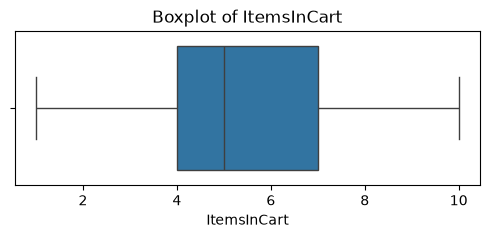

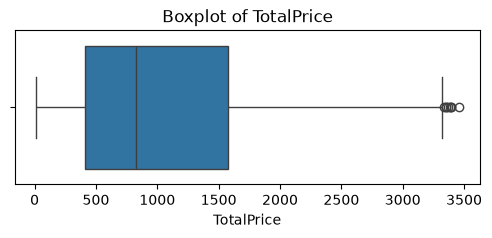

In [23]:
for col in numerical_columns:

    plt.figure(figsize=(6,2))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

In [24]:
z_scores = np.abs(stats.zscore(df[numerical_columns]))

outliers = (z_scores > 3)

print("Outliers in each column:")

print(outliers.sum(axis=0))

Outliers in each column:
[0 0 0 0]


In [25]:
df_zscore = df[(z_scores < 3).all(axis=1)]

print("Original Shape:", df.shape)

print("After Removing Outliers:", df_zscore.shape)

Original Shape: (1200, 19)
After Removing Outliers: (1200, 19)


In [26]:
Q1 = df[numerical_columns].quantile(0.25)

Q3 = df[numerical_columns].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

In [27]:
df_iqr = df[
    ~(
        (
            (df[numerical_columns] < lower)
            |
            (df[numerical_columns] > upper)
        ).any(axis=1)
    )
]

print(df_iqr.shape)

(1192, 19)


In [28]:
encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

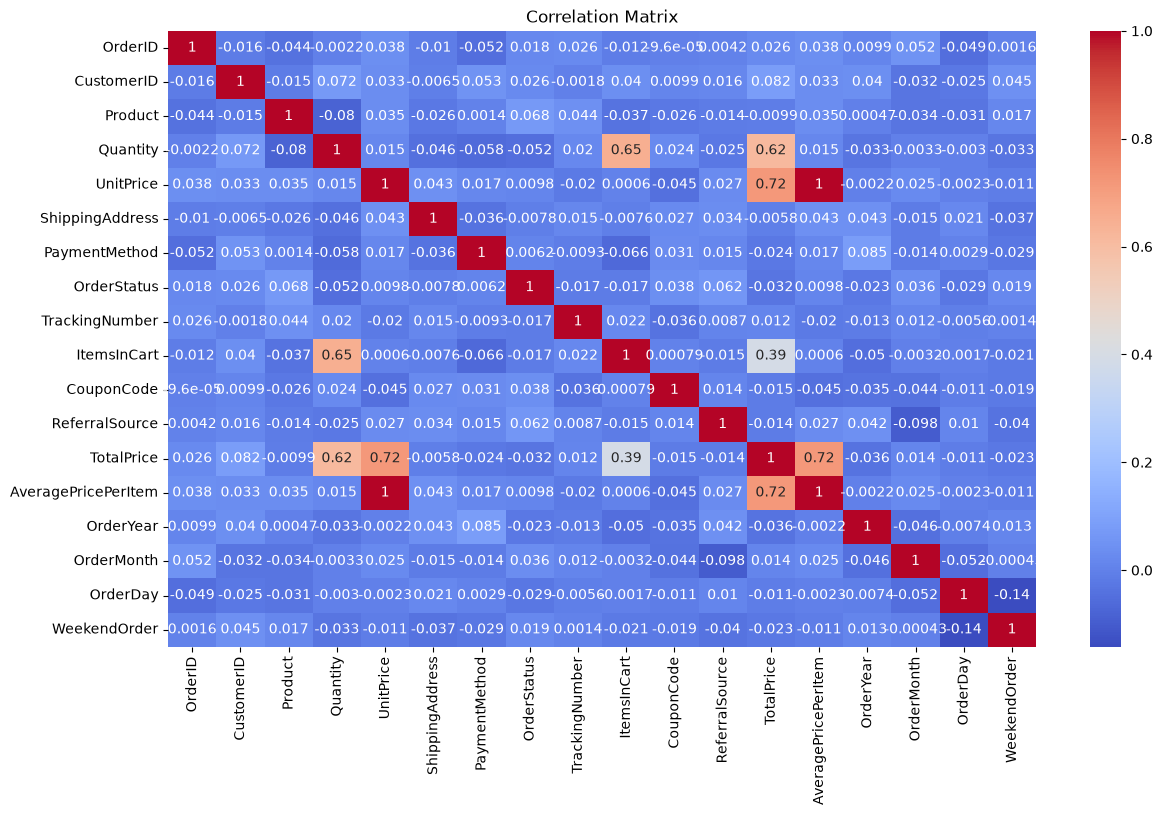

In [29]:
plt.figure(figsize=(14,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [30]:
scaler = StandardScaler()

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [31]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,AveragePricePerItem,OrderYear,OrderMonth,OrderDay,WeekendOrder
0,0,2023-01-04,856,3,1.459993,1.086822,596,2,4,359,0.664173,1,3,2.195362,570.62,2023,4,6,False
1,1,2024-08-23,888,4,-0.672248,-1.040426,512,4,4,1074,-1.089419,1,4,-0.916723,151.35,2024,1,0,False
2,2,2024-02-27,950,6,1.459993,0.985653,294,1,0,416,1.102571,0,0,2.073705,550.68,2024,3,5,False
3,3,2023-10-15,332,0,-1.382995,-0.422247,124,2,3,691,-0.212623,1,1,-0.952732,273.19,2023,10,3,True
4,4,2025-05-08,951,5,0.749246,1.367855,407,4,1,245,1.102571,1,0,1.769427,626.01,2025,8,4,False


In [32]:

df.to_excel("Cleaned_Dataset.xlsx", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!
